# Check PCA Basis
March 18 2026

The largest difference between the two different PCA basis generation methods is how darks are handled. Initially, the `camwfs-sw` was saved, with the best guess at a dark pulled, and then normalized. This has a likelihood of deviating from what we see on camwfs on sky, where we actually will be using the `aol1_imWFS2`,. This is preferred because we will be using it for the realtime code and also it's just standardized.

In [4]:
import sparkles
from astropy.io import fits
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt

import PCA_plotting as pca_plot

## Checking the PCA 

From this test, we see that there is a significant difference between the PCA basis derived from the processed streamwriter, and the hand done normalization from the raw camwfs frames.

In [3]:
# picking a reference for the three data ouputs
camwfs_sw_calib = '/home/eden/data/sparkPCA/'
imWFS_sw_calib = '/home/eden/data/spark_calib/'

calibrations = os.listdir(camwfs_sw_calib)
print(calibrations)

# Notes, ref 2 is bogus for the onlsky tests 
ref_i = 0

file_cam_dir =  camwfs_sw_calib+ calibrations[ref_i]
file_im_dir = imWFS_sw_calib + calibrations[ref_i]

['sep22_ang18_amp0.030_freq2000', 'sep22_ang45_amp0.020_freq2000', 'sep22_ang45_amp0.050_freq2000']


### Checking PCA images

In [4]:
# load in ref_pca.fits data
data_cam = fits.getdata(file_cam_dir + '/ref_pca.fits').reshape(120,120,3)
data_im = fits.getdata(file_im_dir + '/ref_pca.fits').reshape(120,120,3)


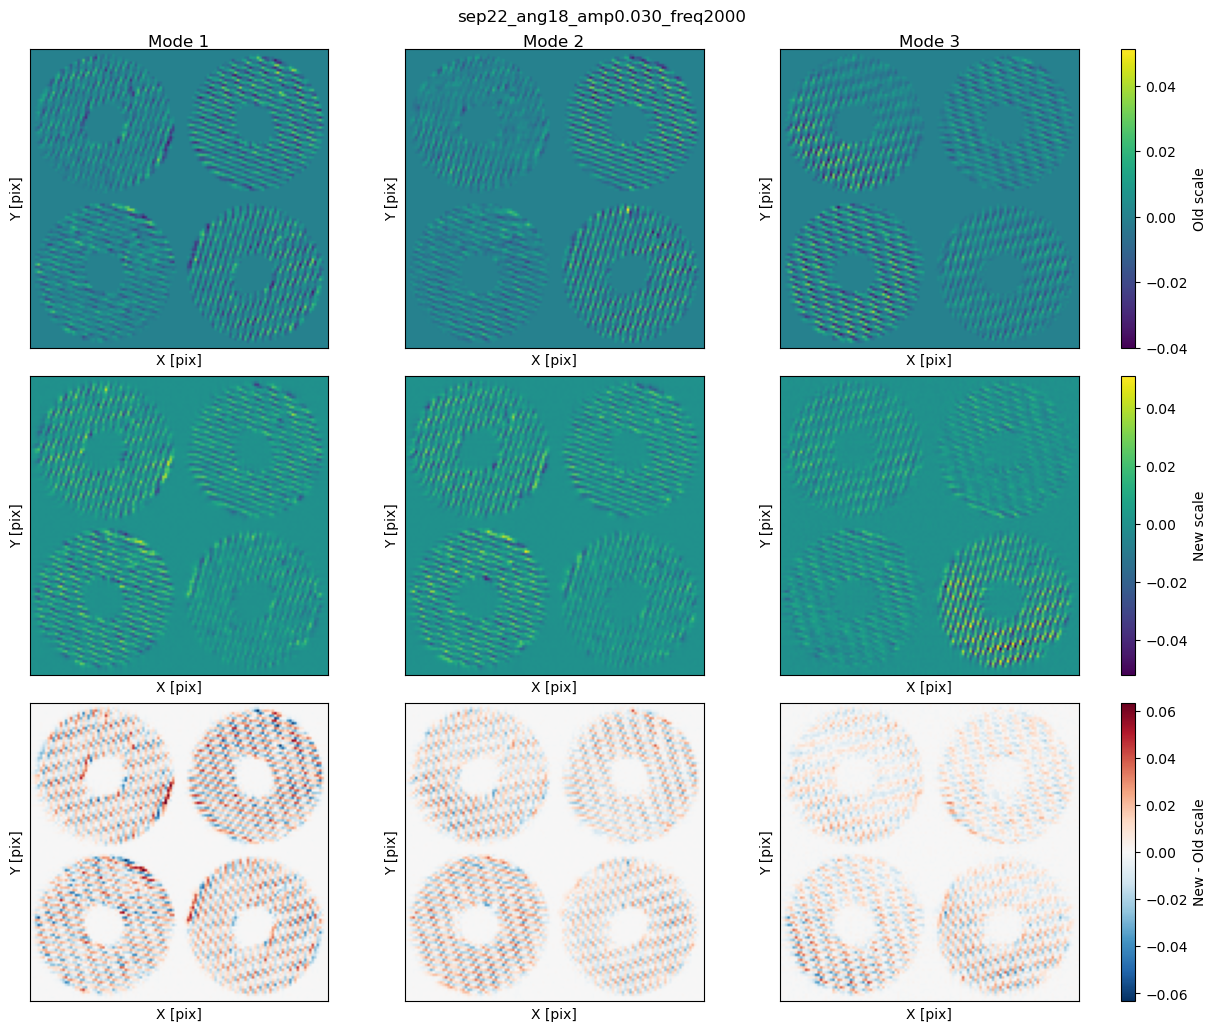

In [5]:
fig = pca_plot.plot_pca_rows_with_difference(data_cam.T, data_im.T, row_labels=("Old", "New", "New - Old"))
plt.suptitle(calibrations[ref_i])
plt.show()

### Checking the self projection averages

In [6]:
# load in ref_pca.fits data
proj_cam = fits.getdata(file_cam_dir + '/ref_proj.fits')
proj_im = fits.getdata(file_im_dir + '/ref_proj.fits')

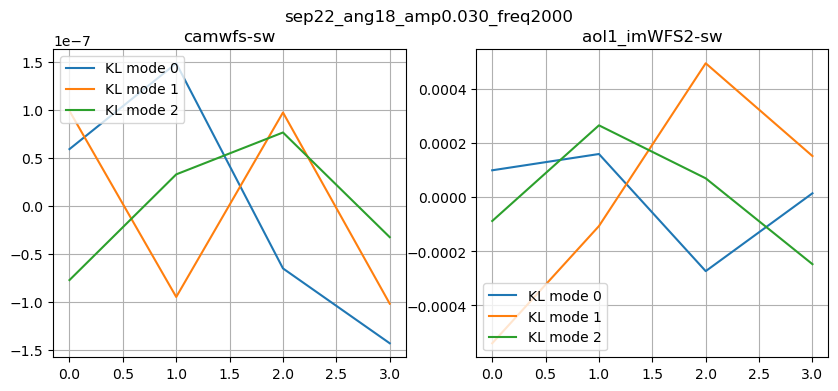

In [15]:

fig = plt.figure(figsize=(10,4))
plt.suptitle(calibrations[ref_i])

plt.subplot(1,2,1)
plt.grid(which='major')
plt.title('camwfs-sw')
for i in range(3):
   plt.plot(proj_cam[:,i], label=f'KL mode {i}')
plt.legend(loc='upper left')


plt.subplot(1,2,2)
plt.grid()
plt.title('aol1_imWFS2-sw')
for i in range(3):
   plt.plot(proj_im[:,i], label=f'KL mode {i}')
plt.legend(loc='lower left')

plt.show()

### Checking the RMS values

In [16]:
# load in ref_pca.fits data
rms_cam = fits.getdata(file_cam_dir + '/ref_rms.fits')
rms_im = fits.getdata(file_im_dir + '/ref_rms.fits')

In [17]:
rms_cam

array([1.12042502e-07, 9.81868972e-08, 5.90621219e-08], dtype='>f8')

In [18]:
rms_im

array([0.00057891, 0.00057342, 0.00026021], dtype='>f8')

## Checking calibration methods on two data streams

In [1]:
from importlib import reload
import calibrator.spark_calib_dual as sc
import sparkles.file_read as file_read


In [2]:
reload(sc)
calib_cls = sc.SparkCalibDual
cspk = calib_cls()

In [ ]:
# calibration directories
calib_dual_onsky_dir = "/home/eden/data/spark_dual"
calib_AO_test_dir = "/home/eden/data/spark_AO"
calib_AO_tests = os.listdir(calib_AO_test_dir)

print(calib_AO_tests)

['AO_1.0', 'AO_0.5', 'AO_noHO']


In [6]:
calibration_folder = calib_AO_test_dir + '/' + calib_AO_tests[0]
sparkle_calib_dirs = os.listdir(calibration_folder)

sparkle_calib_dirs

['sep20_ang45_amp0.050_freq2000',
 'sep20_ang45_amp0.040_freq2000',
 'sep20_ang45_amp0.030_freq2000',
 'sep20_ang45_amp0.020_freq2000']

In [7]:
folder  = calibration_folder + '/' + sparkle_calib_dirs[0]
params = file_read.parse_sparkle_params_from_test_folder(folder)

cspk.setup(calibration_folder, params['sep'], params['ang'], params['amp'], params['freq'])

True

#### Checking the pixel distribution with the 

In [8]:
# set up the calibrator
cspk.read_savedata()

# then get each streamwriter to load in the data 
data_camwfs = cspk.load_streamwriter_data("camwfs-sw")
data_imwfs = cspk.load_streamwriter_data("aol1_imWFS2-sw")

Found 27 files in /opt/MagAOX/rawimages/camwfs/2026_03_19
Found 2 files between camwfs_20260319210233212013000.xrif and camwfs_20260319210235787034000.xrif
Found 44 files in /opt/MagAOX/rawimages/aol1_imWFS2/2026_03_19
Found 2 files between aol1_imWFS2_20260319210233212013000.xrif and aol1_imWFS2_20260319210235787034000.xrif


In [12]:
np.mean(data_imwfs, axis=0, keepdims=True).shape

(1, 120, 120)

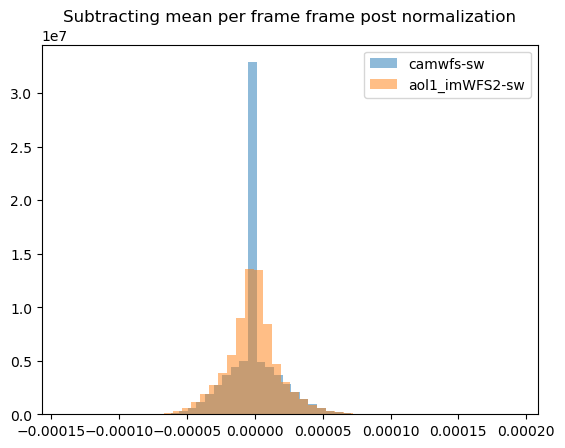

In [9]:
plt.title("Subtracting mean per frame frame post normalization")
plt.hist(data_camwfs.flatten(), bins=50, alpha=0.5, label='camwfs-sw'   )
plt.hist(data_imwfs.flatten(), bins=50, alpha=0.5,  label='aol1_imWFS2-sw')

plt.legend()


## Check the PCA basis against AO responses

In [81]:
def load_pca_basis(folder: str, calib_no: int, streamwriter: str):
    calib_tests = os.listdir(folder)
    calibration_folder = folder + '/' + calib_tests[calib_no]
    imWFS_sw_calib = os.path.join(calibration_folder, streamwriter)
    imWFS_sw_pca = os.path.join(imWFS_sw_calib, 'ref_pca.fits')
    imWFS_sw_pca_data = fits.getdata(imWFS_sw_pca).reshape(120,120,3)
    return calib_tests[calib_no], imWFS_sw_pca_data        

In [82]:
def load_pca_basis_dual(folder: str, calib_no: int):
    calib_tests = os.listdir(folder)
    
    calibration_folder = folder + '/' + calib_tests[calib_no]
    imWFS_sw_calib = os.path.join(calibration_folder, 'aol1_imWFS2-sw')
    camwfs_sw_calib = os.path.join(calibration_folder, 'camwfs-sw')
    
    imWFS_sw_pca = os.path.join(imWFS_sw_calib, 'ref_pca.fits')
    camwfs_sw_pca = os.path.join(camwfs_sw_calib, 'ref_pca.fits')

    imWFS_sw_pca_data = fits.getdata(imWFS_sw_pca).reshape(120,120,3)
    camwfs_sw_pca_data = fits.getdata(camwfs_sw_pca).reshape(120,120,3)
    
    return calib_tests[calib_no], imWFS_sw_pca_data, camwfs_sw_pca_data        

In [69]:
# calibration directories
calib_dual_onsky_dir = "/home/eden/data/spark_dual"
calib_AO_test_dir = "/home/eden/data/spark_AO"
calib_AO_tests = os.listdir(calib_AO_test_dir)

calib_idx = 2

calibration_folder = calib_AO_test_dir + '/' + calib_AO_tests[calib_idx]
print(calibration_folder)
print(os.listdir(calibration_folder))

/home/eden/data/spark_AO/AO_noHO
['sep20_ang45_amp0.050_freq2000', 'sep20_ang45_amp0.040_freq2000', 'sep20_ang45_amp0.030_freq2000', 'sep20_ang45_amp0.020_freq2000']


In [ ]:
test_calib_no = 0
test_calib_name, imWFS_sw_pca_data, camwfs_sw_pca_data = load_pca_basis_dual(calibration_folder, test_calib_no)

In [67]:
# multiplying negatives till it looks right 
# broadcasting the negative sign to the right shape
scalings = [1,-1,1]
camwfs_sw_pca_data_scaled = camwfs_sw_pca_data.T * np.array(scalings).reshape(3,1,1)

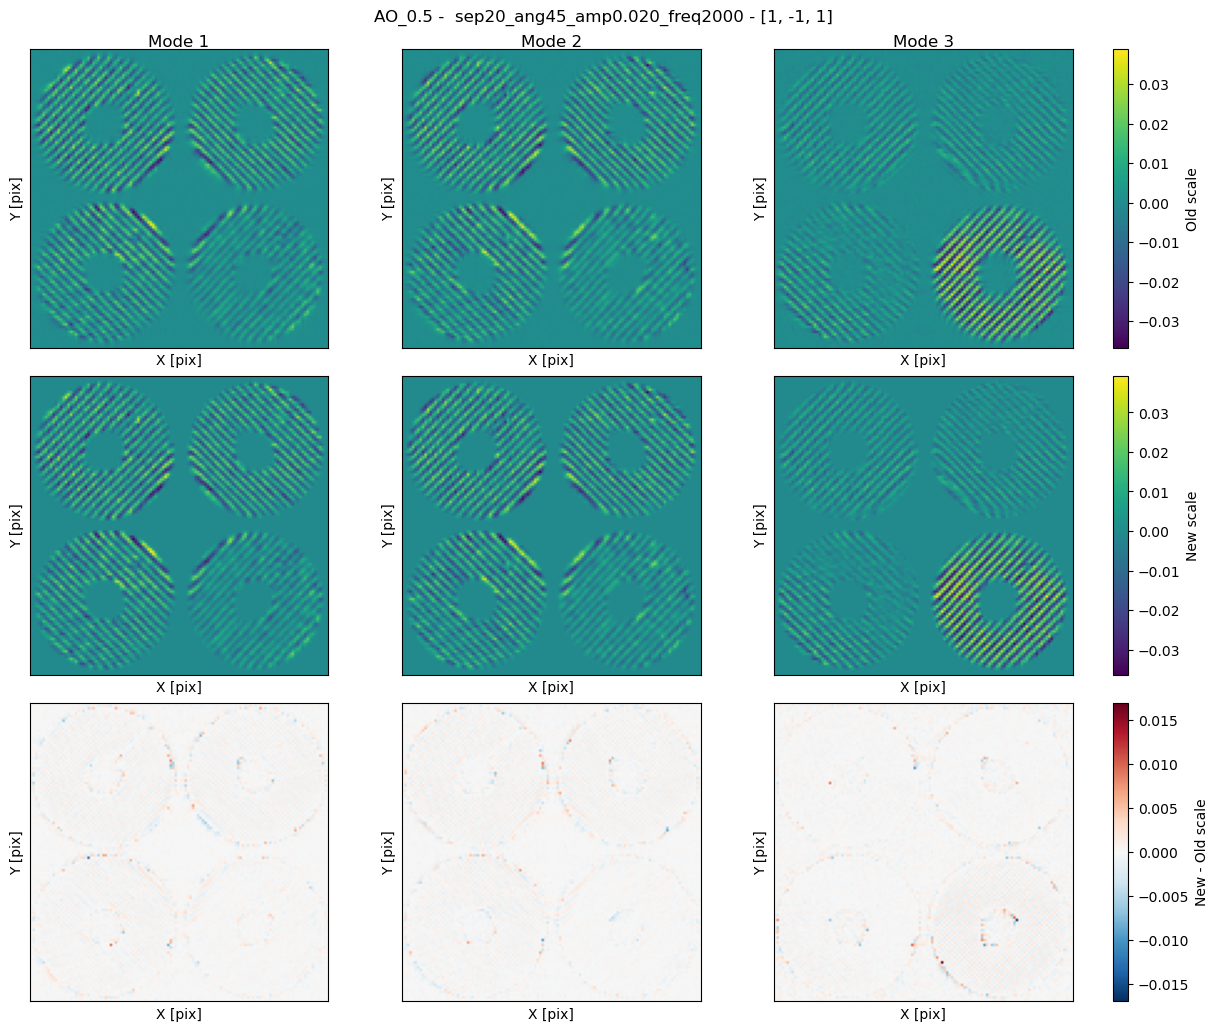

In [68]:
# load the AO response data, plot the PCA basis between the two streamwriters

fig = pca_plot.plot_pca_rows_with_difference(imWFS_sw_pca_data.T, camwfs_sw_pca_data_scaled, row_labels=("Old", "New", "New - Old"))
plt.suptitle(calib_AO_tests[calib_idx] + ' -  ' + test_calib_name + ' - ' + str(scalings))
plt.show()

### Comparing across AO states

In [83]:
# I need a way of showing the differences between the PCA basis sets from 1.0, 0.5 and noHO
AO_dirs = [calib_AO_test_dir + '/' + AO for AO in calib_AO_tests]

# open the same calibration folder and plot for the different AO cases
AO_data = [load_pca_basis(AO_dir, 0, 'aol1_imWFS2-sw') for AO_dir in AO_dirs]

In [ ]:
for calib_ttl, data in AO_data:
    plt.title(calib_ttl)

    


['sep20_ang45_amp0.050_freq2000',
 'sep20_ang45_amp0.040_freq2000',
 'sep20_ang45_amp0.030_freq2000',
 'sep20_ang45_amp0.020_freq2000']

In [88]:
def ao_sort_key(name: str):
    lower = name.lower()
    if 'noho' in lower:
        return (2, 0.0, lower)
    match = re.search(r'([0-9]+\.?[0-9]*)', lower)
    if match:
        # sort numeric AO cases by descending gain: 1.0, 0.5, ...
        return (0, -float(match.group(1)), lower)
    return (1, 0.0, lower)

def load_pca_basis_sorted(folder: str, calib_no: int, sw: str):
    calib_tests = sorted(os.listdir(folder))
    calibration_folder = os.path.join(folder, calib_tests[calib_no])
    sw_calib = os.path.join(calibration_folder, sw)
    pca_path = os.path.join(sw_calib, 'ref_pca.fits')
    pca_data = fits.getdata(pca_path).reshape(120, 120, 3)
    return calib_tests[calib_no], pca_data

def pca_mode_norms(pca_cube: np.ndarray) -> np.ndarray:
    flat = pca_cube.reshape(-1, pca_cube.shape[-1])
    return np.linalg.norm(flat, axis=0)

def pca_mode_rms(pca_cube: np.ndarray) -> np.ndarray:
    flat = pca_cube.reshape(-1, pca_cube.shape[-1])
    return np.sqrt(np.mean(flat**2, axis=0))

In [95]:
# Compare PCA mode strengths/ratios across AO states (1.0, 0.5, noHO)
import re

streamwriter = 'aol1_imWFS2-sw'
calib_test_no = 3  # same calibration index across each AO test folder

calib_AO_tests_sorted = sorted(calib_AO_tests, key=ao_sort_key)
AO_dirs = [os.path.join(calib_AO_test_dir, AO) for AO in calib_AO_tests_sorted]

mode_norms_by_ao = {}
calib_names_by_ao = {}
mode_rms_by_ao = {}

for ao_name, ao_dir in zip(calib_AO_tests_sorted, AO_dirs):
    calib_name, pca_data = load_pca_basis_sorted(ao_dir, calib_test_no, streamwriter)
    mode_norms_by_ao[ao_name] = pca_mode_norms(pca_data)
    mode_rms_by_ao[ao_name] = pca_mode_rms(pca_data)
    calib_names_by_ao[ao_name] = calib_name

# Reference AO state: prefer AO=1.0 if available, else first in sorted order
ref_ao_name = next((name for name in calib_AO_tests_sorted if '1.0' in name), calib_AO_tests_sorted[0])
ref_norms = mode_norms_by_ao[ref_ao_name]
mode_idx = np.arange(1, ref_norms.size + 1)

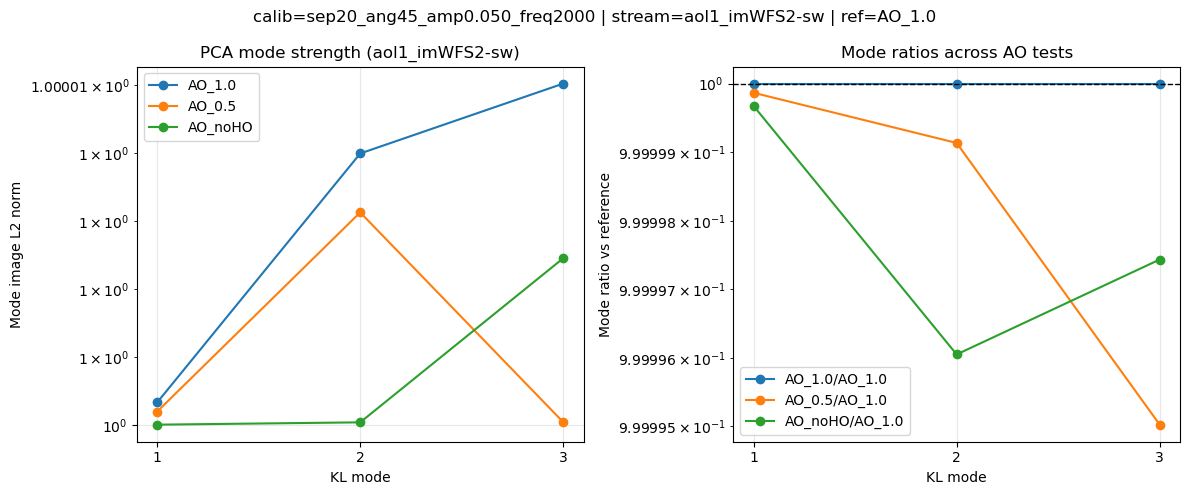

In [107]:
# Re-plot with integer-only x-axis tick marks
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
for ao_name in calib_AO_tests_sorted:
    ax1.plot(mode_idx, mode_norms_by_ao[ao_name], marker='o', label=ao_name)
ax1.set_xlabel('KL mode')
ax1.set_ylabel('Mode image L2 norm')
ax1.set_title(f'PCA mode strength ({streamwriter})')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_xticks(mode_idx)
ax1.set_yscale('log')
ax1.grid(alpha=0.3)
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
for ao_name in calib_AO_tests_sorted:
    ratios = np.divide(mode_norms_by_ao[ao_name], ref_norms, where=ref_norms != 0)
    ax2.plot(mode_idx, ratios, marker='o', label=f'{ao_name}/{ref_ao_name}')
ax2.axhline(1.0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel('KL mode')
ax2.set_ylabel('Mode ratio vs reference')
ax2.set_title('Mode ratios across AO tests')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xticks(mode_idx)
ax2.set_yscale('log')
ax2.grid(alpha=0.3)
ax2.legend()

plt.suptitle(f'calib={common_calib} | stream={streamwriter} | ref={ref_ao_name}')
plt.tight_layout()
plt.show()

### checking across AO 1.0, see if the strength changes the return

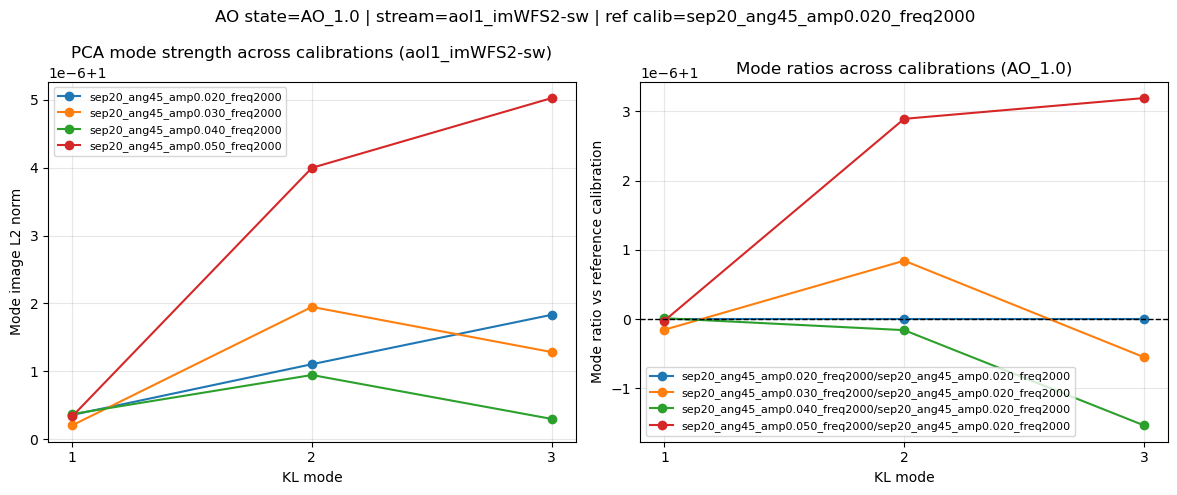

AO state: AO_1.0
Calibrations: ['sep20_ang45_amp0.020_freq2000', 'sep20_ang45_amp0.030_freq2000', 'sep20_ang45_amp0.040_freq2000', 'sep20_ang45_amp0.050_freq2000']
Reference calibration: sep20_ang45_amp0.020_freq2000


In [109]:
# Same plot style, but iterate over calibrations inside AO_1.0
from matplotlib.ticker import MaxNLocator

streamwriter = 'aol1_imWFS2-sw'

# Find AO_1.0 folder name robustly
ao_10_name = next((name for name in calib_AO_tests if '1.0' in name), None)
if ao_10_name is None:
    raise ValueError('Could not find an AO_1.0 entry in calib_AO_tests')

ao_10_dir = os.path.join(calib_AO_test_dir, ao_10_name)
calib_names_sorted = sorted(
    [name for name in os.listdir(ao_10_dir) if os.path.isdir(os.path.join(ao_10_dir, name))]
)

def pca_mode_norms(pca_cube: np.ndarray) -> np.ndarray:
    flat = pca_cube.reshape(-1, pca_cube.shape[-1])
    return np.linalg.norm(flat, axis=0)

mode_norms_by_calib = {}

for calib_name in calib_names_sorted:
    pca_path = os.path.join(ao_10_dir, calib_name, streamwriter, 'ref_pca.fits')
    pca_data = fits.getdata(pca_path).reshape(120, 120, 3)
    mode_norms_by_calib[calib_name] = pca_mode_norms(pca_data)

# Reference calibration for ratio plot (change index if desired)
ref_calib_idx = 0
ref_calib_name = calib_names_sorted[ref_calib_idx]
ref_norms = mode_norms_by_calib[ref_calib_name]
mode_idx = np.arange(1, ref_norms.size + 1)

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
for calib_name in calib_names_sorted:
    ax1.plot(mode_idx, mode_norms_by_calib[calib_name], marker='o', label=calib_name)
ax1.set_xlabel('KL mode')
ax1.set_ylabel('Mode image L2 norm')
ax1.set_title(f'PCA mode strength across calibrations ({streamwriter})')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_xticks(mode_idx)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

ax2 = plt.subplot(1, 2, 2)
for calib_name in calib_names_sorted:
    ratios = np.divide(mode_norms_by_calib[calib_name], ref_norms, where=ref_norms != 0)
    ax2.plot(mode_idx, ratios, marker='o', label=f'{calib_name}/{ref_calib_name}')
ax2.axhline(1.0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel('KL mode')
ax2.set_ylabel('Mode ratio vs reference calibration')
ax2.set_title('Mode ratios across calibrations (AO_1.0)')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xticks(mode_idx)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

plt.suptitle(f'AO state={ao_10_name} | stream={streamwriter} | ref calib={ref_calib_name}')
plt.tight_layout()
plt.show()

print('AO state:', ao_10_name)
print('Calibrations:', calib_names_sorted)
print('Reference calibration:', ref_calib_name)

In [ ]:
# Same AO_1.0 calibration plot with legend simplified to amplitude only
from matplotlib.ticker import MaxNLocator

streamwriter = 'aol1_imWFS2-sw'
ao_10_name = next((name for name in calib_AO_tests if '1.0' in name), None)
if ao_10_name is None:
    raise ValueError('Could not find an AO_1.0 entry in calib_AO_tests')

ao_10_dir = os.path.join(calib_AO_test_dir, ao_10_name)
calib_names_sorted = sorted(
    [name for name in os.listdir(ao_10_dir) if os.path.isdir(os.path.join(ao_10_dir, name))]
)

def pca_mode_norms(pca_cube: np.ndarray) -> np.ndarray:
    flat = pca_cube.reshape(-1, pca_cube.shape[-1])
    return np.linalg.norm(flat, axis=0)

def amp_label(calib_name: str) -> str:
    for part in calib_name.split('_'):
        if part.startswith('amp'):
            return part
    return calib_name

mode_norms_by_calib = {}
for calib_name in calib_names_sorted:
    pca_path = os.path.join(ao_10_dir, calib_name, streamwriter, 'ref_pca.fits')
    pca_data = fits.getdata(pca_path).reshape(120, 120, 3)
    mode_norms_by_calib[calib_name] = pca_mode_norms(pca_data)

ref_calib_idx = 0
ref_calib_name = calib_names_sorted[ref_calib_idx]
ref_norms = mode_norms_by_calib[ref_calib_name]
mode_idx = np.arange(1, ref_norms.size + 1)

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
for calib_name in calib_names_sorted:
    ax1.plot(mode_idx, mode_norms_by_calib[calib_name], marker='o', label=amp_label(calib_name))
ax1.set_xlabel('KL mode')
ax1.set_ylabel('Mode image L2 norm')
ax1.set_title(f'PCA mode strength across calibrations ({streamwriter})')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_xticks(mode_idx)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

ax2 = plt.subplot(1, 2, 2)
for calib_name in calib_names_sorted:
    ratios = np.divide(mode_norms_by_calib[calib_name], ref_norms, where=ref_norms != 0)
    ax2.plot(mode_idx, ratios, marker='o', label=f"{amp_label(calib_name)}/{amp_label(ref_calib_name)}")
ax2.axhline(1.0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel('KL mode')
ax2.set_ylabel('Mode ratio vs reference calibration')
ax2.set_title('Mode ratios across calibrations (AO_1.0)')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xticks(mode_idx)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

plt.suptitle(f'AO state={ao_10_name} | stream={streamwriter} | ref calib={amp_label(ref_calib_name)}')
plt.tight_layout()
plt.show()